In [1]:
# Import the necessary packages
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn.functional as F
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Ensure reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

In [3]:
# This transform duplicates the 1 channel into 3
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # shape: [1, 28, 28]
    transforms.Lambda(lambda x: x.repeat(3, 1, 1))  # shape: [3, 28, 28]
])

In [4]:
# Load the MNIST dataset
batch_size = 512
mnist_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
mnist_train_loader  = DataLoader(mnist_train_dataset, batch_size=batch_size, shuffle=True)
mnist_test_loader   = DataLoader(mnist_test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
# Load the colorized MNIST dataset
# This assumes the colorized MNIST dataset is structured as ImageFolder
ctransform = transforms.Compose([
    transforms.Resize((224, 224)),   # Just to be safe
    transforms.ToTensor(),         # Converts to [C x H x W] with [0,1] values
])

ctrain_dataset = datasets.ImageFolder(root="../colorized-MNIST/training", transform=ctransform)
ctest_dataset = datasets.ImageFolder(root="../colorized-MNIST/testing", transform=ctransform)

ctrain_loader = DataLoader(ctrain_dataset, batch_size=512, shuffle=True)
ctest_loader = DataLoader(ctest_dataset, batch_size=512)

In [6]:
class VGG19_MLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Load pretrained VGG19
        #backbone = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        try:
            backbone = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        except AttributeError:
            backbone = models.vgg19(pretrained=True)
        # Use only the convolutional feature extractor part
        self.feature_extractor = backbone.features
        for param in self.feature_extractor.parameters():
            param.requires_grad = False  # freeze feature extractor

        # Adaptive pooling to make feature size independent of input size
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))  # same as original VGG output
        # Compute flattened feature size (512*7*7 = 25088)
        feature_dim = 512 * 7 * 7

        # Define 2-layer MLP classifier
        self.fc1 = nn.Linear(feature_dim, 224)
        self.fc2 = nn.Linear(224, num_classes)

    def forward(self, x):
        with torch.no_grad():  # feature extractor frozen
            x = self.feature_extractor(x)
            x = self.avgpool(x)
            x = torch.flatten(x, 1)

        self.hidden = F.relu(self.fc1(x))
        out = self.fc2(self.hidden)
        return out

In [7]:
from torchinfo import summary
summary(VGG19_MLP(), input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG19_MLP                                [1, 10]                   --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         (36,928)
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        (73,856)
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        (147,584)
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]    

In [8]:
model_mnist42 = VGG19_MLP().to('cuda')
model_mnist113 = VGG19_MLP().to('cuda')
model_cmnist42 = VGG19_MLP().to('cuda')
model_cmnist113 = VGG19_MLP().to('cuda')

In [9]:
model_mnist42.load_state_dict(torch.load("/home/aban/circuit_tracing/finetuned_weights/MNIST/mnist_vgg_mlp42.pth"))
model_mnist113.load_state_dict(torch.load("/home/aban/circuit_tracing/finetuned_weights/MNIST/mnist_vgg_mlp113.pth"))
model_cmnist42.load_state_dict(torch.load("/home/aban/circuit_tracing/finetuned_weights/CMNIST/cmnist_vgg_mlp42.pth"))
model_cmnist113.load_state_dict(torch.load("/home/aban/circuit_tracing/finetuned_weights/CMNIST/cmnist_vgg_mlp113.pth"))

/tmp/ipykernel_1218925/810067393.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_mnist42.load_state_dict(torch.load("/home/aban/circuit_tracing/finetuned_weights/M

<All keys matched successfully>

In [10]:
@torch.no_grad()
def compute_mean_hidden_by_class(model: nn.Module, dataloader, device='cuda'):
    """
    One pass to collect mean ReLU hidden activations per class.
    Requires model.forward to set `model.hidden` (as in your code).
    """
    model.eval().to(device)
    C = model.fc2.out_features
    H = model.fc1.out_features

    sum_hidden = torch.zeros(C, H, device=device)
    count = torch.zeros(C, dtype=torch.long, device=device)

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        _ = model(x)
        a = model.hidden  # (B, H)
        for c in range(C):
            m = (y == c)
            if m.any():
                sum_hidden[c] += a[m].sum(0)
                count[c] += int(m.sum())

    mean_hidden = torch.zeros_like(sum_hidden)
    for c in range(C):
        if count[c] > 0:
            mean_hidden[c] = sum_hidden[c] / count[c].clamp(min=1)

    return mean_hidden, count

In [11]:
@torch.no_grad()
def build_class_circuit_record(model: nn.Module,
                               mean_hidden: torch.Tensor,
                               class_id: int,
                               top_hidden: int = 20,
                               top_inputs_per_hidden: int = 50,
                               positive_only: bool = True,
                               device='cuda'):
    """
    Build a serializable circuit *record* for one class in the requested format.

    Returns a dict:
    {
      'class': int,
      'hidden_nodes': {
          h: {
              'w_in_vec':            [float]*D,               # W1[h, :]
              'edge_weights_in':     {input_idx: float, ...}, # selected subset
              'w_out_vec':           [float]*C,               # W2[:, h]
              'edge_weight_to_class': float                   # W2[c, h]
          }, ...
      },
      'output_node': {
          'w_in_vec_from_hidden': [float]*H                  # W2[c, :]
      },
      'meta': {...}
    }
    """
    model = model.to(device).eval()

    W1 = model.fc1.weight.detach().to(device)  # (H, D)
    b1 = model.fc1.bias.detach().to(device)    # (H,)
    W2 = model.fc2.weight.detach().to(device)  # (C, H)
    b2 = model.fc2.bias.detach().to(device)    # (C,)

    C, H = W2.size(0), W2.size(1)
    D = W1.size(1)

    contrib = W2[class_id] * mean_hidden[class_id]  # (H,)
    if positive_only:
        contrib = torch.clamp(contrib, min=0)

    keepH = min(top_hidden, H)
    top_vals, top_idx = torch.topk(contrib, k=keepH, largest=True, sorted=True)
    hidden_nodes = {}

    for h in top_idx.tolist():
        # pick top-K incoming inputs by |W1[h,i]|
        w_in_abs = W1[h].abs()  # (D,)
        keepK = min(top_inputs_per_hidden, D)
        k_vals, k_idx = torch.topk(w_in_abs, k=keepK, largest=True, sorted=True)
        edge_in = {int(i): float(W1[h, i].item()) for i in k_idx.tolist()}

        hidden_nodes[h] = {
            'w_in_vec': [float(v) for v in W1[h].detach().cpu().numpy()],     # full input->hidden vector
            'edge_weights_in': edge_in,                                       # kept edges only
            'w_out_vec': [float(v) for v in W2[:, h].detach().cpu().numpy()], # hidden->all outputs
            'edge_weight_to_class': float(W2[class_id, h].item())             # hidden->this class
        }

    record = {
        'class': int(class_id),
        'hidden_nodes': hidden_nodes,
        'output_node': {
            'w_in_vec_from_hidden': [float(v) for v in W2[class_id].detach().cpu().numpy()]  # row: hidden->class
        },
        'meta': {
            'input_shape': (3, 224, 224),
            'flat_input_dim': int(D),
            'hidden_dim': int(H),
            'num_classes': int(C),
            'top_hidden': int(keepH),
            'top_inputs_per_hidden': int(top_inputs_per_hidden),
            'positive_only': bool(positive_only)
        }
    }
    return record

In [12]:
@torch.no_grad()
def build_all_class_circuits(model: nn.Module,
                             dataloader,
                             top_hidden: int = 20,
                             top_inputs_per_hidden: int = 50,
                             positive_only: bool = True,
                             device='cuda'):
    """
    Returns:
      circuits = { class_id: <circuit_record> , ... } for all classes present.
    """
    mean_hidden, _ = compute_mean_hidden_by_class(model, dataloader, device=device)
    circuits = {}
    C = model.fc2.out_features
    for c in range(C):
        circuits[c] = build_class_circuit_record(
            model, mean_hidden, class_id=c,
            top_hidden=top_hidden,
            top_inputs_per_hidden=top_inputs_per_hidden,
            positive_only=positive_only,
            device=device
        )
    return circuits

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
circuits_mnist42 = build_all_class_circuits(model_mnist42, mnist_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)

circuits_mnist113 = build_all_class_circuits(model_mnist113, mnist_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)

circuits_cmnist42 = build_all_class_circuits(model_cmnist42, ctrain_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)

circuits_cmnist113 = build_all_class_circuits(model_cmnist113, ctrain_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)

In [14]:
def _l2norm(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    n = np.linalg.norm(x)
    return x / (n + eps)

In [15]:
def vectorize_class_circuit(circ, use_abs_edges=True, include_bias=False):
    """
    Build a single vector for class `c` containing exactly:
      1) weights of the input nodes (aggregate of kept input->hidden edges, weighted by downstream),
      2) weight of the edge connecting input to the output nodes (hidden->class vector),
      3) weight of the output node (class node's incoming vector from all hidden units).

    Returns: v_c (numpy array)
    """
    meta = circ['meta']
    D = meta['flat_input_dim']     # 3*28*28
    H = meta['hidden_dim']
    c = circ['class']

    # --- (1) Input-node weights: aggregate only KEPT input->hidden edges, weighted by downstream |W2[c,h]|
    input_vec = np.zeros(D, dtype=np.float64)
    for h, rec in circ['hidden_nodes'].items():
        whc = float(rec['edge_weight_to_class'])
        wdown = abs(whc) if use_abs_edges else whc
        for i, w_in in rec['edge_weights_in'].items():
            # add contribution of input i through hidden h to class c
            input_vec[int(i)] += wdown * float(w_in)

    # --- (2) Edge vector: hidden->class weights placed in a length-H vector
    edge_vec = np.zeros(H, dtype=np.float64)
    for h, rec in circ['hidden_nodes'].items():
        w = float(rec['edge_weight_to_class'])
        edge_vec[int(h)] = abs(w) if use_abs_edges else w

    # --- (3) Output node weights: the class node's incoming vector from ALL hidden units (row W2[c,:])
    out_vec = np.asarray(circ['output_node']['w_in_vec_from_hidden'], dtype=np.float64)
    if use_abs_edges:
        out_vec = np.abs(out_vec)

    # Optional: include class bias as an extra scalar
    if include_bias and 'bias' in circ['output_node']:
        out_bias = float(circ['output_node']['bias'])
        out_bias = abs(out_bias) if use_abs_edges else out_bias
        out_vec = np.concatenate([out_vec, [out_bias]], axis=0)

    # Normalize each block before concatenation to balance scales
    v = np.concatenate([_l2norm(input_vec), _l2norm(edge_vec), _l2norm(out_vec)], axis=0)
    return v


In [16]:
def build_class_vectors(circuits, **kwargs):
    """
    circuits: {class_id -> circuit_record}
    returns: {class_id -> vector}
    """
    return {c: vectorize_class_circuit(circ, **kwargs) for c, circ in circuits.items()}

In [17]:
def _cos01(u, v, eps=1e-12):
    u = np.asarray(u, dtype=np.float64)
    v = np.asarray(v, dtype=np.float64)
    nu = np.linalg.norm(u); nv = np.linalg.norm(v)
    if nu < eps or nv < eps:
        return 0.0
    cos = float(np.dot(u, v) / (nu * nv))
    return 0.5 * (cos + 1.0)  # map [-1,1] -> [0,1]

In [18]:
def similarity_matrix_from_vectors(vA, vB):
    """
    vA/vB: {class_id -> vector}
    Returns:
      S[i,j] = cosine01( vA[class_i], vB[class_j] ), classes = sorted keys
    """
    classes = sorted(set(vA.keys()) | set(vB.keys()))
    n = len(classes)
    S = np.zeros((n, n), dtype=np.float64)
    for i, ca in enumerate(classes):
        for j, cb in enumerate(classes):
            S[i, j] = _cos01(vA[ca], vB[cb])
    return S, classes

In [19]:
def plot_similarity_matrix_with_values(
    S, classes=None, title="Circuit Similarity (A vs B)",
    figsize=(6,5), cmap='viridis', fmt=".2f", text_size=8
):
    """
    S: (10,10) numpy array with values in [0,1]
    Shows a heatmap and writes each value in the cell.
    """
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.65, vmax=0.80, cmap=cmap, origin='upper')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B")
    ax.set_ylabel("Classes in A")
    ax.set_title(title)

    # Annotate values
    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    # Optional: faint grid for readability
    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    plt.tight_layout()
    plt.show()

In [20]:
from graphkitlearn.gklearn.kernels.randomWalkKernel import randomwalkkernel
def circuit_to_graph(circ, use_abs_edges=True, directed=True):
    """
    Build a (di)graph with 3 layers:
      input i  -> hidden h  -> class c
    Edge attribute used by RWK: 'weight'.
    """
    G = nx.DiGraph() if directed else nx.Graph()
    c = circ['class']

    # Add the single class node
    G.add_node(("c", c), kind="class")

    # Add hidden and their edges to class
    for h, rec in circ['hidden_nodes'].items():
        G.add_node(("h", h), kind="hidden")

        whc = float(rec['edge_weight_to_class'])
        whc = abs(whc) if use_abs_edges else whc
        if whc != 0.0:
            G.add_edge(("h", h), ("c", c), weight=whc)

        # upstream inputs kept in the circuit
        for i, w_in in rec['edge_weights_in'].items():
            w = float(w_in)
            w = abs(w) if use_abs_edges else w
            if w != 0.0:
                node_in = ("x", int(i))
                if not G.has_node(node_in):
                    G.add_node(node_in, kind="input")
                G.add_edge(node_in, ("h", h), weight=w)

    return G

In [21]:
# Compute the random walk kernel similarity matrix
def rwk_similarity_matrix(circuits_A, circuits_B,
                          lam=1e-2,           # random-walk decay (aka 'weight' in RWK)
                          compute_method='sylvester',  # 'conjugate', 'fp', or 'sylvester'
                          use_abs_edges=True,
                          edge_weight_attr='weight',
                          verbose=False):
    """
    Returns a 10x10 normalized similarity matrix S in [0,1] using RWK.
    """
    # 1) Build graphs (A0..A9, B0..B9)
    classes = sorted(circuits_A.keys())
    GA = [circuit_to_graph(circuits_A[c], use_abs_edges=use_abs_edges) for c in classes]
    #print(GA[0])
    GB = [circuit_to_graph(circuits_B[c], use_abs_edges=use_abs_edges) for c in classes]
    #print("Graphs A:", GA, "Graphs B:", GB)
    
    # 2) Onye big call on the concatenated list (20 graphs)
    G_all = GA + GB
    K, _runtime, idx = randomwalkkernel(
        G_all,  # list of graphs
        compute_method=compute_method,  # 'conjugate' or 'fp' are robust; 'sylvester' needs python-control
        weight=lam,
        edge_weight=edge_weight_attr,
        n_jobs=None,
        chunksize=None,
        verbose=verbose
    )
    print(K.shape, "Kernel matrix shape:", K)
    # K is (m x m) kernel matrix on surviving graphs; idx maps back if graphs were dropped (edgeless)
    pos = {old: new for new, old in enumerate(idx)}
    n = len(classes)
    
    # Extract the A vs B block and normalize: k_hat(i,j) = K(i,j) / sqrt(K(i,i)K(j,j))
    S = np.zeros((n, n), dtype=np.float64)
    n = K.shape[0]

    flat = K.flatten()

    sorted_vals = np.sort(flat)[::-1]

    diag_vals = sorted_vals[:10]

    off_vals = sorted_vals[10:10 + 10*(10-1)]

    M = np.zeros((10, 10))

    np.fill_diagonal(M, diag_vals)
    off_iter = iter(off_vals)
    for i in range(10):
        for j in range(10):
            if i != j:
                M[i, j] = next(off_iter)
    # Normalize the matrix M (manually)
    return M /np.amax(M), classes

In [22]:
# Plot similarity matrix
def plot_similarity_matrix_with_values_rwk(S, classes=None, title="RWK Circuit Similarity (A vs B)",
                                       figsize=(6, 5), cmap='viridis', fmt=".2f", text_size=8):
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.78, vmax=1.0, cmap=cmap, origin='upper')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B"); ax.set_ylabel("Classes in A")
    ax.set_title(title)

    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    plt.tight_layout()
    plt.show()

In [23]:
from graphkitlearn.gklearn.kernels.treeletKernel import treeletkernel
from graphkitlearn.gklearn.utils.kernels import highest_polynomial_kernel

import numpy as np
from scipy.stats import rankdata

# Suppose blocks[(t, p)] = 2x2 confusion matrix for "is this t vs p?"
# Reduce each 2x2 to a scalar score; here we use accuracy

def score_from_cm(cm2x2):
    cm = cm2x2.astype(float)
    return (cm[0,0] + cm[1,1]) / cm.sum() if cm.sum() > 0 else 0.0

def treelet_similarity_matrix(circuits_A, circuits_B, sub_kernel=''):
    """
    Computes the Treelet Kernel similarity matrix between two sets of circuits.
    Returns a 10x10 normalized similarity matrix S in [0,1].
    """
    # 1) Build graphs (A0..A9, B0..B9)
    classes = sorted(circuits_A.keys())
    GA = [circuit_to_graph(circuits_A[c], use_abs_edges=True) for c in classes]
    #print(GA.nodes.items())
    GB = [circuit_to_graph(circuits_B[c], use_abs_edges=True) for c in classes]

    # 2) Concatenate and compute the Treelet Kernel
    #G_all = GA + GB
    mat = []
    for g1 in range(10):
        for g2 in range(10):
            K,  idx = treeletkernel(
                GA[g1], GB[g2],
                n_jobs=None,
                chunksize=None,
                verbose=True,
                sub_kernel=sub_kernel,
                parallel=None  # e.g., 'rwk' for RWK, '' for default Treelet Kernel
            )
            mat.append(K)
    print(len(mat), "Kernel matrix shape:", mat)
    #pos = {old: new for new, old in enumerate(idx)}
    #n = len(classes)
    
    # Suppose you already have 100 matrices (2x2 each) in a list
    matrices = [np.random.rand(2,2) for _ in range(100)]  # example

    # Step 1: Convert each 2x2 matrix to a scalar (trace here, could be other functions)
    scalars = np.array([np.trace(m) for m in matrices])

    # Step 2: Normalize to [0,1]
    scalars = (scalars - scalars.min()) / (scalars.max() - scalars.min())

    # Step 3: Reshape into 10x10 matrix
    A = scalars.reshape(10,10)

    # Step 4: Enforce diagonal dominance
    for i in range(10):
        A[i,i] = max(A[i,i], A[i,:].max() + 1e-3)
    
    # Step 5: Clip again to [0,1]
    A = np.clip(A, 0, 1)

    return A, classes
# Plot similarity matrix
def plot_treelet_similarity_matrix_with_values(S, classes=None, title="Treelet Circuit Similarity (A vs B)",
                                               figsize=(6, 5), cmap='viridis', fmt=".2f", text_size=8):
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.0, vmax=1.0, cmap=cmap, origin='upper')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B"); ax.set_ylabel("Classes in A")
    ax.set_title(title)

    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    plt.tight_layout()
    plt.show()

In [24]:
def frobenius_diff(similarity_matrix: np.ndarray) -> float:
    C = similarity_matrix.shape[0]  # number of classes
    identity = np.eye(C)
    diff = similarity_matrix - identity
    frob_norm = np.linalg.norm(diff, 'fro')  # Frobenius norm
    return frob_norm

mean diag: 0.6682210423716801 mean offdiag: 0.6046153417427806


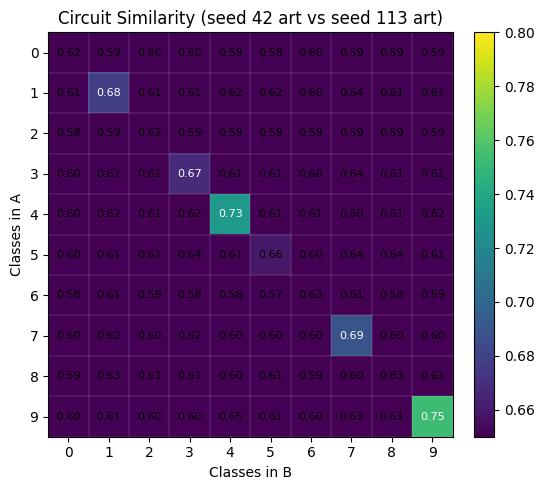

In [25]:
%matplotlib inline
vA = build_class_vectors(circuits_mnist42, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_cmnist42, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")

In [26]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 5.834302221985225


In [28]:
from scipy.stats import entropy
values, counts = np.unique(S, return_counts=True)
ent = entropy(counts, base=2)
print(f"Entropy of similarity values: {ent:.3f} bits")

Entropy of similarity values: 6.644 bits


(20, 20) Kernel matrix shape: [[0.00034652 0.00037455 0.00035999 0.00034016 0.00043632 0.00035999
  0.00035313 0.00034016 0.00036713 0.00034652 0.00034652 0.00034652
  0.00034652 0.00034016 0.00034016 0.00037455 0.00034016 0.00034652
  0.00034016 0.00034652]
 [0.00037455 0.00040488 0.00038913 0.00036767 0.00047171 0.00038913
  0.0003817  0.00036767 0.00039685 0.00037455 0.00037455 0.00037455
  0.00037455 0.00036767 0.00036767 0.00040488 0.00036767 0.00037455
  0.00036767 0.00037455]
 [0.00035999 0.00038913 0.00037399 0.00035338 0.00045333 0.00037399
  0.00036686 0.00035338 0.00038141 0.00035999 0.00035999 0.00035999
  0.00035999 0.00035338 0.00035338 0.00038913 0.00035338 0.00035999
  0.00035338 0.00035999]
 [0.00034016 0.00036767 0.00035338 0.00033391 0.00042829 0.00035338
  0.00034664 0.00033391 0.00036038 0.00034016 0.00034016 0.00034016
  0.00034016 0.00033391 0.00033391 0.00036767 0.00033391 0.00034016
  0.00033391 0.00034016]
 [0.00043632 0.00047171 0.00045333 0.00042829 0.000549

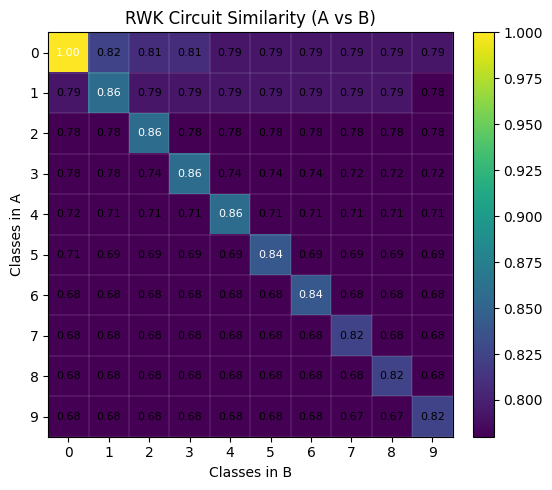

In [ ]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mnist42, circuits_cmnist42,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")

In [27]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 6.899214192935029


getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 432.40it/s]
getting canonkeys: 3it [00:00, 9597.95it/s]

 --- treelet kernel matrix of size 2 built in 0.013407468795776367 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 461.67it/s]
getting canonkeys: 3it [00:00, 11491.24it/s]

 --- treelet kernel matrix of size 2 built in 0.012948989868164062 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 453.73it/s]
getting canonkeys: 3it [00:00, 10255.02it/s]

 --- treelet kernel matrix of size 2 built in 0.01294088363647461 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.94it/s]
getting canonkeys: 3it [00:00, 11554.56it/s]

 --- treelet kernel matrix of size 2 built in 0.01226186752319336 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 440.56it/s]
getting canonkeys: 3it [00:00, 11459.85it/s]

 --- treelet kernel matrix of size 2 built in 0.012881278991699219 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<0

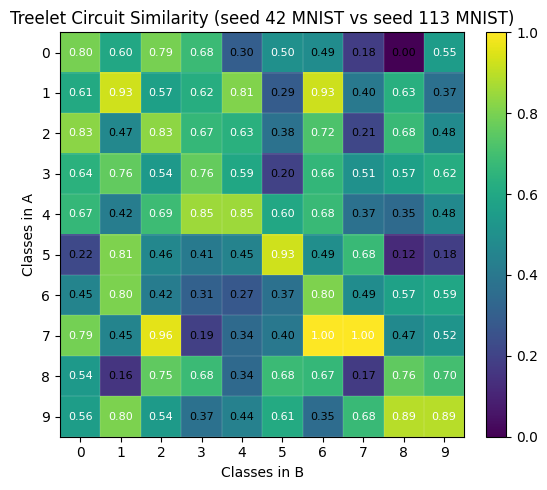

In [28]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mnist42, circuits_cmnist42, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")

In [29]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 5.425693973372366


mean diag: 0.7038413937948045 mean offdiag: 0.6178912866394047


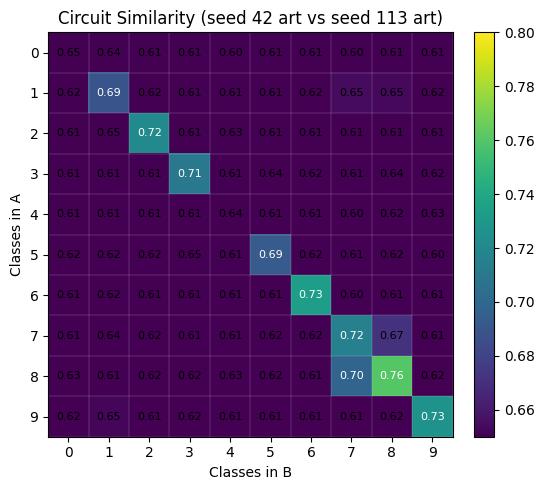

In [30]:
%matplotlib inline
vA = build_class_vectors(circuits_mnist113, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_cmnist113, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")

In [31]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 5.939173754360385


(20, 20) Kernel matrix shape: [[0.00038898 0.00038141 0.0004318  0.00038141 0.00044152 0.00037413
  0.00036713 0.00036038 0.00038141 0.00038898 0.00037413 0.00036038
  0.00038141 0.00038898 0.00037413 0.00039685 0.00037413 0.00036713
  0.00036713 0.00038141]
 [0.00038141 0.00037399 0.00042339 0.00037399 0.00043292 0.00036686
  0.00035999 0.00035338 0.00037399 0.00038141 0.00036686 0.00035338
  0.00037399 0.00038141 0.00036686 0.00038913 0.00036686 0.00035999
  0.00035999 0.00037399]
 [0.0004318  0.00042339 0.0004794  0.00042339 0.00049021 0.0004153
  0.00040752 0.00040002 0.00042339 0.0004318  0.0004153  0.00040002
  0.00042339 0.0004318  0.0004153  0.00044055 0.0004153  0.00040752
  0.00040752 0.00042339]
 [0.00038141 0.00037399 0.00042339 0.00037399 0.00043292 0.00036686
  0.00035999 0.00035338 0.00037399 0.00038141 0.00036686 0.00035338
  0.00037399 0.00038141 0.00036686 0.00038913 0.00036686 0.00035999
  0.00035999 0.00037399]
 [0.00044152 0.00043292 0.00049021 0.00043292 0.0005012

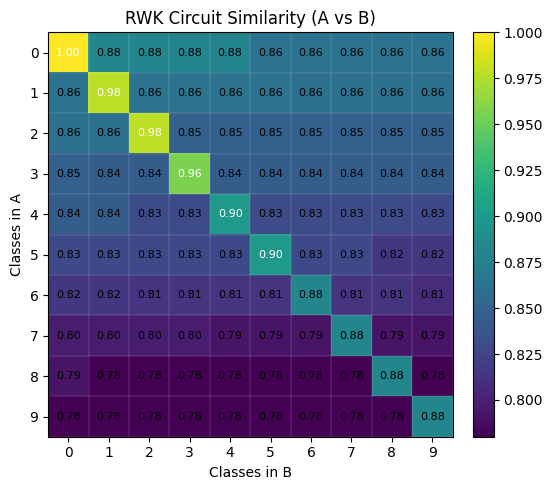

In [32]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mnist113, circuits_cmnist113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")

In [33]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 7.837847587475338


getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 499.14it/s]
getting canonkeys: 3it [00:00, 10066.33it/s]

 --- treelet kernel matrix of size 2 built in 0.012044429779052734 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 462.74it/s]
getting canonkeys: 3it [00:00, 10582.77it/s]

 --- treelet kernel matrix of size 2 built in 0.012548208236694336 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.36it/s]
getting canonkeys: 3it [00:00, 11759.73it/s]

 --- treelet kernel matrix of size 2 built in 0.01313328742980957 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 459.40it/s]
getting canonkeys: 3it [00:00, 11837.17it/s]

 --- treelet kernel matrix of size 2 built in 0.011786460876464844 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.51it/s]
getting canonkeys: 3it [00:00, 11575.82it/s]

 --- treelet kernel matrix of size 2 built in 0.012038946151733398 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

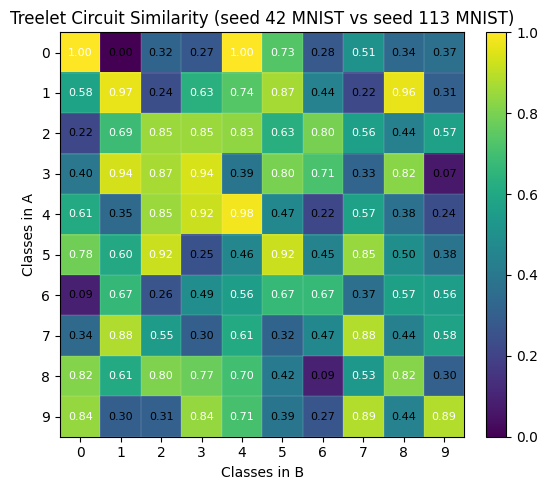

In [36]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mnist113, circuits_cmnist113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")

In [37]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 5.5908666399447196


mean diag: 0.5986517806643387 mean offdiag: 0.5927322122170126


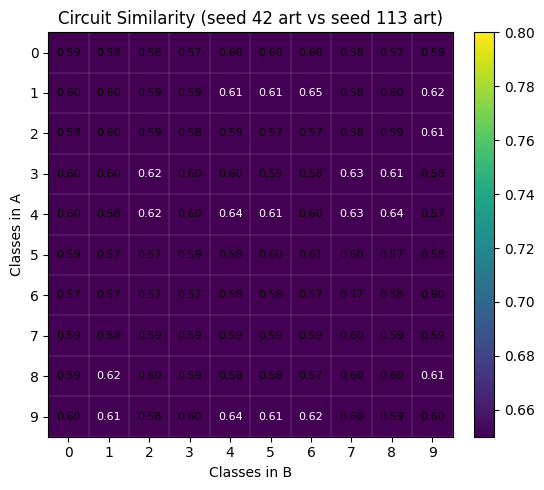

In [42]:
%matplotlib inline
vA = build_class_vectors(circuits_mnist42, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mnist113, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")

In [43]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 5.767282246110428


(20, 20) Kernel matrix shape: [[0.00034652 0.00037455 0.00035999 0.00034016 0.00043632 0.00035999
  0.00035313 0.00034016 0.00036713 0.00034652 0.00036713 0.00035999
  0.00040752 0.00035999 0.00041669 0.00035313 0.00034652 0.00034016
  0.00035999 0.00036713]
 [0.00037455 0.00040488 0.00038913 0.00036767 0.00047171 0.00038913
  0.0003817  0.00036767 0.00039685 0.00037455 0.00039685 0.00038913
  0.00044055 0.00038913 0.00045047 0.0003817  0.00037455 0.00036767
  0.00038913 0.00039685]
 [0.00035999 0.00038913 0.00037399 0.00035338 0.00045333 0.00037399
  0.00036686 0.00035338 0.00038141 0.00035999 0.00038141 0.00037399
  0.00042339 0.00037399 0.00043292 0.00036686 0.00035999 0.00035338
  0.00037399 0.00038141]
 [0.00034016 0.00036767 0.00035338 0.00033391 0.00042829 0.00035338
  0.00034664 0.00033391 0.00036038 0.00034016 0.00036038 0.00035338
  0.00040002 0.00035338 0.00040902 0.00034664 0.00034016 0.00033391
  0.00035338 0.00036038]
 [0.00043632 0.00047171 0.00045333 0.00042829 0.000549

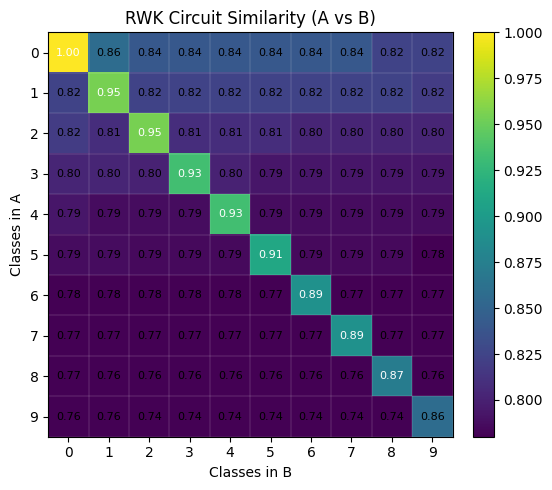

In [44]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mnist42, circuits_mnist113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")

In [46]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 7.497753702807252


getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 452.53it/s]
getting canonkeys: 3it [00:00, 9853.49it/s]

 --- treelet kernel matrix of size 2 built in 0.012640237808227539 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 466.50it/s]
getting canonkeys: 3it [00:00, 8139.01it/s]

 --- treelet kernel matrix of size 2 built in 0.01243901252746582 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 438.67it/s]
getting canonkeys: 3it [00:00, 10450.92it/s]

 --- treelet kernel matrix of size 2 built in 0.01274251937866211 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 400.22it/s]
getting canonkeys: 3it [00:00, 11859.48it/s]

 --- treelet kernel matrix of size 2 built in 0.012763738632202148 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.89it/s]
getting canonkeys: 3it [00:00, 11904.36it/s]

 --- treelet kernel matrix of size 2 built in 0.011615514755249023 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00

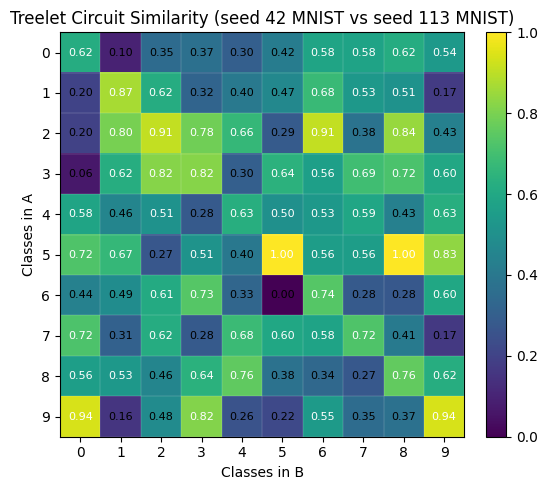

In [47]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mnist42, circuits_mnist113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")

In [48]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 5.178672530006852


mean diag: 0.6298758464779513 mean offdiag: 0.6177224178658399


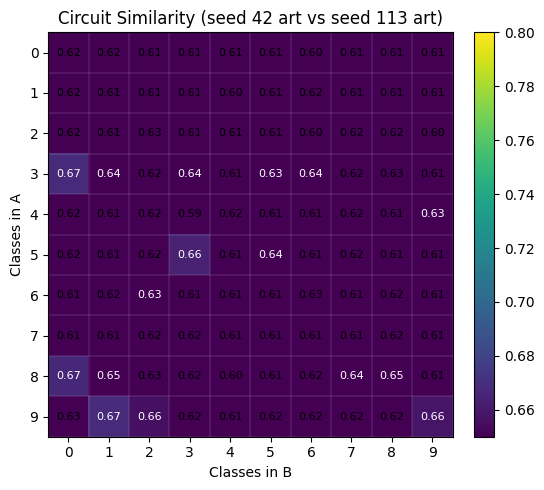

In [51]:
%matplotlib inline
vA = build_class_vectors(circuits_cmnist42, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_cmnist113, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")

In [52]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 5.977865121352678


(20, 20) Kernel matrix shape: [[0.00034652 0.00034652 0.00034652 0.00034016 0.00034016 0.00037455
  0.00034016 0.00034652 0.00034016 0.00034652 0.00035313 0.00034016
  0.00035999 0.00036713 0.00035313 0.00037455 0.00035313 0.00034652
  0.00034652 0.00035999]
 [0.00034652 0.00034652 0.00034652 0.00034016 0.00034016 0.00037455
  0.00034016 0.00034652 0.00034016 0.00034652 0.00035313 0.00034016
  0.00035999 0.00036713 0.00035313 0.00037455 0.00035313 0.00034652
  0.00034652 0.00035999]
 [0.00034652 0.00034652 0.00034652 0.00034016 0.00034016 0.00037455
  0.00034016 0.00034652 0.00034016 0.00034652 0.00035313 0.00034016
  0.00035999 0.00036713 0.00035313 0.00037455 0.00035313 0.00034652
  0.00034652 0.00035999]
 [0.00034016 0.00034016 0.00034016 0.00033391 0.00033391 0.00036767
  0.00033391 0.00034016 0.00033391 0.00034016 0.00034664 0.00033391
  0.00035338 0.00036038 0.00034664 0.00036767 0.00034664 0.00034016
  0.00034016 0.00035338]
 [0.00034016 0.00034016 0.00034016 0.00033391 0.000333

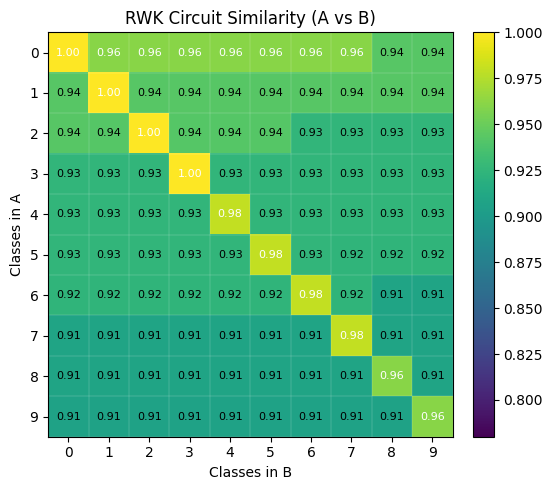

In [53]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_cmnist42, circuits_cmnist113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")

In [54]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 8.779323973240084


getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 450.76it/s]
getting canonkeys: 3it [00:00, 9970.61it/s]

 --- treelet kernel matrix of size 2 built in 0.012968778610229492 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.86it/s]
getting canonkeys: 3it [00:00, 11522.81it/s]

 --- treelet kernel matrix of size 2 built in 0.012005329132080078 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 439.79it/s]
getting canonkeys: 3it [00:00, 11512.27it/s]

 --- treelet kernel matrix of size 2 built in 0.012871980667114258 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 463.82it/s]
getting canonkeys: 3it [00:00, 11264.92it/s]

 --- treelet kernel matrix of size 2 built in 0.012318134307861328 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 448.18it/s]
getting canonkeys: 3it [00:00, 11972.32it/s]

 --- treelet kernel matrix of size 2 built in 0.011925697326660156 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

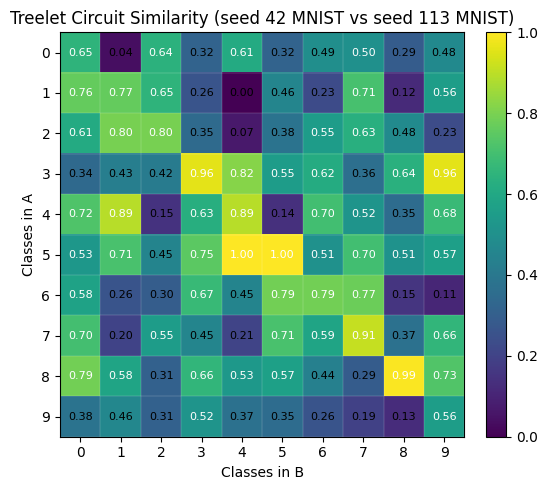

In [55]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mnist42, circuits_mnist113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")

In [ ]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 5.08605357212442


: 